In [1]:
import torch
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.metrics import r2_score
import random
import matplotlib as mpl
import os
import gc
import pandas as pd
import csv
from numpy import *

from torch.utils.tensorboard import SummaryWriter
from datetime import date
# from generate_property import output_property

2026-05-29 19:55:45.782441: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-29 19:55:45.819060: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 19:55:46.474003: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
data = np.load('data.npy', allow_pickle=True)

# make dict of data with column 0 as key and column 1 as values
data_dict = {}
for i in range(len(data)):
    key = data[i][0]
    value = data[i][1]
    data_dict[key] = value
np.save('data_dict.npy', data_dict)

print(data_dict['GTCATGTT'])

0.7817733826124598


In [3]:
from generate_property import output_property_oracle
output_property_oracle = output_property_oracle()
prop = output_property_oracle.output_property(['GTCATGTT'])
print(prop)

[0.78177338]


In [4]:
## finding the largest protein
def find_max_len(data):
    max_len = 0
    for i in range(data.shape[0]):
        str_len = list(data[i,0])
        if max_len < len(str_len):
            max_len = len(str_len)
            # print(max_len)
    print('Max len is', max_len)
    return max_len

max_len = find_max_len(data)

Max len is 8


In [5]:
# # different amino acids
amino_acid = ['A', 'G','C','T'] # O is the uncommon amino acid, so total length is 21
# amino_acid = ['A', 'V', 'F', 'I', 'L','D','E','K','S','T','Y','C','N','Q', 'P','M', 'R', 'H', 'W', 'G','X'] # O is the uncommon amino acid, so total length is 21
print('Number of unique amino acids are', np.shape(np.unique(amino_acid))[0])
np.save('categorical_variables', amino_acid)
def onehotseq(sequence):
  aa_seq = ''
  seq_len = len(sequence)
  seq_en = np.zeros(( seq_len, np.shape(amino_acid)[0]))
  act_len = 0
  for i in range(seq_len):
    if sequence[i] in amino_acid:
      pos = amino_acid.index(sequence[i])
      seq_en[act_len,pos] = 1
      act_len += 1  
      aa_seq += sequence[i]    
    elif (sequence[i] not in amino_acid) and (sequence[i] != " ") and (sequence[i] != '\ufeff'):
      pos = amino_acid.index('X')
      seq_en[act_len,pos] = 1
      act_len += 1 
      aa_seq += sequence[i]
  return seq_en[0:act_len, :], aa_seq

Number of unique amino acids are 4


In [6]:
# max_len = find_max_len(data)
ohe = np.zeros((data.shape[0], max_len, len(amino_acid)))  ## batch size*sequenc_len*4
seq_string = np.zeros((data.shape[0],), dtype=object) ## it will store the string of nucleotides
seq_lengths = np.zeros((data.shape[0],))
tm = np.zeros((data.shape[0], 1))

for i in range(ohe.shape[0]):
    seq_en, aa_seq = onehotseq(list(data[i,0]))
    seq_string[i,] = aa_seq
    ohe[i,0:seq_en.shape[0],:] =  seq_en
    seq_lengths[i,] = seq_en.shape[0]
    tm[i,0] = data[i,1]

output_y = tm
seq_length = seq_lengths

print(f'Total samples before filtering: {len(ohe)}')
print(f'Y range: min={output_y.min():.4f}, max={output_y.max():.4f}')

# Filter to keep only sequences with y <= 0.2
cutoff = 0.2
filter_idx = output_y.flatten() <= cutoff
ohe = ohe[filter_idx]
seq_string = seq_string[filter_idx]
seq_length = seq_length[filter_idx]
output_y = output_y[filter_idx]

print(f'After filtering (y <= {cutoff}): {len(ohe)} samples')
print(f'Y range after filtering: min={output_y.min():.4f}, max={output_y.max():.4f}')

Total samples before filtering: 65792
Y range: min=0.0000, max=1.0000
After filtering (y <= 0.2): 2980 samples
Y range after filtering: min=0.0000, max=0.2000


In [ ]:
all_ex = np.arange(ohe.shape[0])
x_train, x_temp, _, _ = train_test_split(all_ex, all_ex, test_size=0.3, random_state=50)
x_valid, x_test, _, _ = train_test_split(x_temp, x_temp, test_size=0.5, random_state=50)

print('Train', x_train.shape)
print('Test', x_test.shape)
print('Valid', x_valid.shape)

print(ohe[x_train].shape, seq_length[x_train].shape, output_y[x_train].shape)

In [8]:
np.save('./x_train', ohe[x_train])
np.save('./len_train', seq_length[x_train])
np.save('./y_train', output_y[x_train])
np.save('./seq_train', seq_string[x_train])

np.save('./x_valid', ohe[x_valid])
np.save('./len_valid', seq_length[x_valid])
np.save('./y_valid', output_y[x_valid])
np.save('./seq_valid', seq_string[x_valid])

np.save('./x_test', ohe[x_test])
np.save('./len_test', seq_length[x_test])
np.save('./y_test', output_y[x_test])
np.save('./seq_test', seq_string[x_test])

    
# np.save('./store_data/x_train'+str(trial), ohe[x_train])
# np.save('./store_data/len_train'+str(trial), seq_length[x_train])
# np.save('./store_data/y_train'+str(trial), output_y[x_train])

# np.save('./store_data/x_valid'+str(trial), ohe[x_valid])
# np.save('./store_data/len_valid'+str(trial), seq_length[x_valid])
# np.save('./store_data/y_valid'+str(trial), output_y[x_valid])

# np.save('./store_data/x_test'+str(trial), ohe[x_test])
# np.save('./store_data/len_test'+str(trial), seq_length[x_test])
# np.save('./store_data/y_test'+str(trial), output_y[x_test])

(array([   0.,    0.,    0.,    0.,    0., 2980.,    0.,    0.,    0.,
           0.]),
 array([7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5]),
 <BarContainer object of 10 artists>)

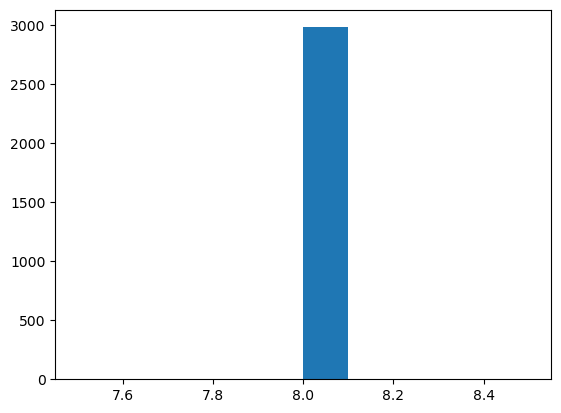

In [9]:
plt.hist(seq_length)

(array([ 16.,  34.,  68., 108., 160., 238., 346., 488., 696., 826.]),
 array([0.        , 0.01999911, 0.03999822, 0.05999734, 0.07999645,
        0.09999556, 0.11999467, 0.13999378, 0.1599929 , 0.17999201,
        0.19999112]),
 <BarContainer object of 10 artists>)

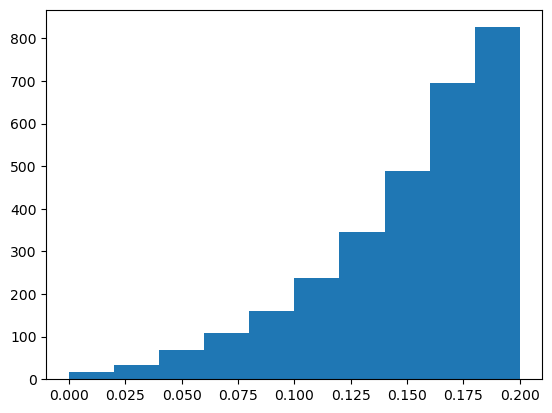

In [10]:
plt.hist(output_y)